In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/raw/food_delivery.csv')
print(df.shape)
print("--------------")
print(df.dtypes)

(45593, 20)
--------------
ID                                 str
Delivery_person_ID                 str
Delivery_person_Age                str
Delivery_person_Ratings            str
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weatherconditions                  str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries                str
Festival                           str
City                               str
Time_taken(min)                    str
dtype: object


In [2]:
print(df.isnull().sum().sum())

0


In [3]:
for col in df.select_dtypes(include='str').columns:
    print(col, df[col].unique()[:10])

ID <ArrowStringArray>
['0x4607 ', '0xb379 ', '0x5d6d ', '0x7a6a ', '0x70a2 ', '0x9bb4 ', '0x95b4 ',
 '0x9eb2 ', '0x1102 ', '0xcdcd ']
Length: 10, dtype: str
Delivery_person_ID <ArrowStringArray>
[  'INDORES13DEL02 ',   'BANGRES18DEL02 ',   'BANGRES19DEL01 ',
  'COIMBRES13DEL02 ',   'CHENRES12DEL01 ',    'HYDRES09DEL03 ',
 'RANCHIRES15DEL01 ',    'MYSRES15DEL02 ',    'HYDRES05DEL02 ',
    'DEHRES17DEL01 ']
Length: 10, dtype: str
Delivery_person_Age <ArrowStringArray>
['37', '34', '23', '38', '32', '22', '33', '35', '36', '21']
Length: 10, dtype: str
Delivery_person_Ratings <ArrowStringArray>
['4.9', '4.5', '4.4', '4.7', '4.6', '4.8', '4.2', '4.3', '4', '4.1']
Length: 10, dtype: str
Order_Date <ArrowStringArray>
['19-03-2022', '25-03-2022', '05-04-2022', '26-03-2022', '11-03-2022',
 '04-03-2022', '14-03-2022', '20-03-2022', '12-02-2022', '13-02-2022']
Length: 10, dtype: str
Time_Orderd <ArrowStringArray>
['11:30:00', '19:45:00', '08:30:00', '18:00:00', '13:30:00', '21:20:00',
 '19:15:00'

In [4]:
disguised_nulls = df.apply(lambda col: col.astype(str).str.strip().str.contains('NaN').sum())
print(disguised_nulls[disguised_nulls > 0])

Delivery_person_Age        1854
Delivery_person_Ratings    1908
Time_Orderd                1731
Weatherconditions           616
Road_traffic_density        601
multiple_deliveries         993
Festival                    228
City                       1200
dtype: int64


In [5]:
for col in df.select_dtypes(include='str').columns:
    mask = df[col].str.contains('NaN', na=False)
    df.loc[mask, col] = np.nan

In [6]:
# Weatherconditions: "conditions Sunny" -> "Sunny"
df['Weatherconditions'] = df['Weatherconditions'].str.replace('conditions ', '', regex=False)

# Time_taken(min): "(min) 24" -> 24 (int)
df['Time_taken(min)'] = df['Time_taken(min)'].str.replace('(min) ', '', regex=False).astype(float)

# numeric columns still stored as text
df['Delivery_person_Age'] = df['Delivery_person_Age'].astype(float)
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].astype(float)
df['multiple_deliveries'] = df['multiple_deliveries'].astype(float)

In [7]:
# numeric imputation
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median())
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median())

# mode imputation
for col in ['Weatherconditions', 'Road_traffic_density', 'multiple_deliveries', 'Festival', 'City']:
    df[col] = df[col].fillna(df[col].mode()[0])

# drop rows with missing order time
df = df.dropna(subset=['Time_Orderd'])
print(df.shape)

(43862, 20)


In [8]:
print(df[['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']].describe())

       Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
count         43862.000000          43862.000000                43862.000000   
mean             17.241971             70.764932                   17.462466   
std               7.698686             21.136195                    7.338540   
min             -30.902872              0.000000                    0.010000   
25%              12.933298             73.170283                   12.986229   
50%              18.554382             75.898497                   18.633934   
75%              22.732225             78.045359                   22.785049   
max              30.914057             88.433452                   31.054057   

       Delivery_location_longitude  
count                 43862.000000  
mean                     70.828527  
std                      21.136365  
min                       0.010000  
25%                      73.279312  
50%                      75.999490  
75%                 

In [9]:
print(df['Time_taken(min)'].describe())

count    43862.000000
mean        26.293831
std          9.373765
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64


In [10]:
for col in ['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']:
    df[col] = df[col].abs()

In [11]:
print(df.duplicated().sum())
print(df.shape)

0
(43862, 20)


In [12]:
mask = (
    (df['Restaurant_latitude'] < 1) | (df['Restaurant_longitude'] < 1) |
    (df['Delivery_location_latitude'] < 1) | (df['Delivery_location_longitude'] < 1)
)
print(mask.sum())
df = df[~mask]
print(df.shape)

3509
(40353, 20)


In [14]:
# numeric columns: mean, median, std
print(df.describe())

       Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  \
count         40353.000000             40353.000000         40353.000000   
mean             29.554829                 4.634387            18.911836   
std               5.746713                 0.313975             5.468296   
min              20.000000                 2.500000             9.957144   
25%              25.000000                 4.500000            12.986047   
50%              30.000000                 4.700000            19.065838   
75%              35.000000                 4.900000            22.751234   
max              39.000000                 5.000000            30.914057   

       Restaurant_longitude  Delivery_location_latitude  \
count          40353.000000                40353.000000   
mean              76.918480                   18.975471   
std                3.500531                    5.470105   
min               72.768726                    9.967144   
25%               73

In [17]:
# categorical columns: frequency counts
categorical_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_order', 
                     'Type_of_vehicle', 'Festival', 'City']
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Weatherconditions:
Weatherconditions
Fog           6845
Stormy        6806
Cloudy        6747
Sandstorms    6717
Windy         6675
Sunny         6563
Name: count, dtype: int64

Road_traffic_density:
Road_traffic_density
Low        13816
Jam        12726
Medium      9836
High        3975
Name: count, dtype: int64

Type_of_order:
Type_of_order
Snack      10196
Meal       10119
Drinks     10059
Buffet      9979
Name: count, dtype: int64

Type_of_vehicle:
Type_of_vehicle
motorcycle           23660
scooter              13489
electric_scooter      3204
Name: count, dtype: int64

Festival:
Festival
No      39566
Yes       787
Name: count, dtype: int64

City:
City
Metropolitian     31279
Urban              8933
Semi-Urban          141
Name: count, dtype: int64


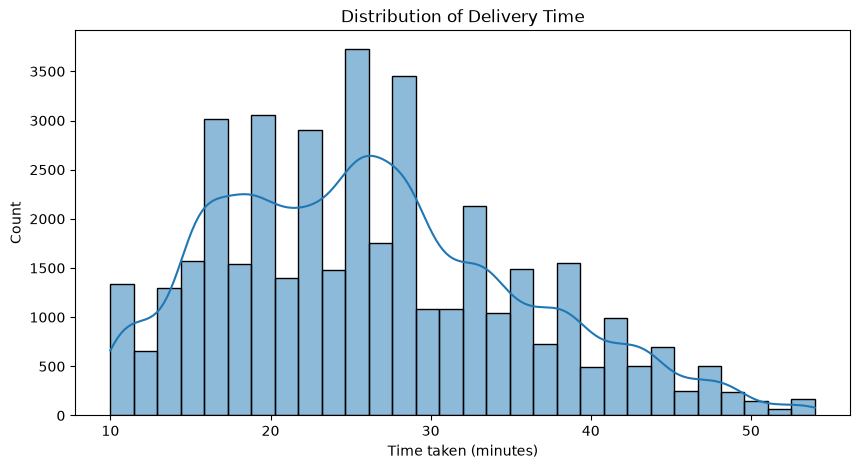

Skewness: 0.4785198260638503


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['Time_taken(min)'], bins=30, kde=True)
plt.title('Distribution of Delivery Time')
plt.xlabel('Time taken (minutes)')
plt.ylabel('Count')
plt.show()

print("Skewness:", df['Time_taken(min)'].skew())

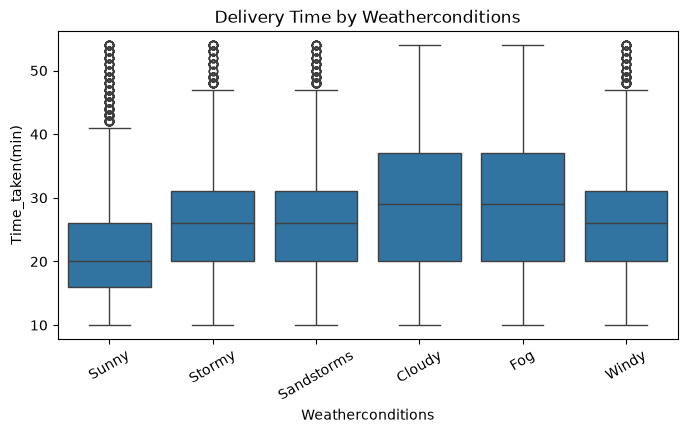

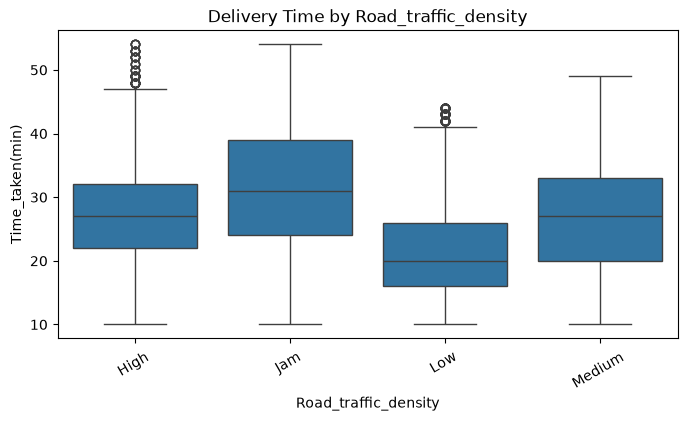

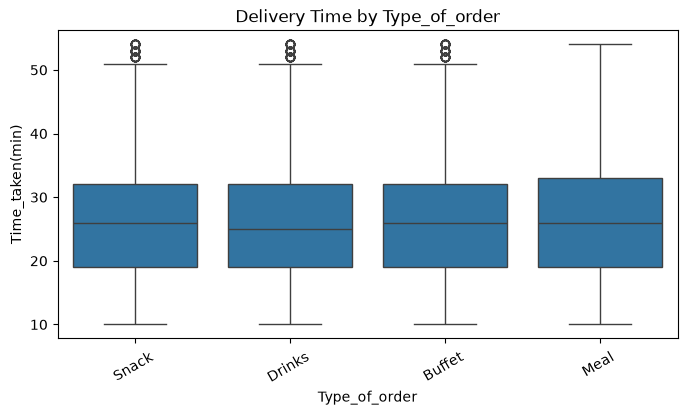

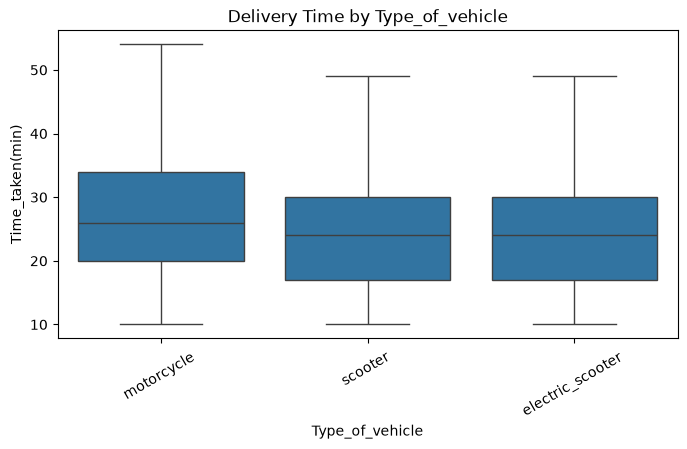

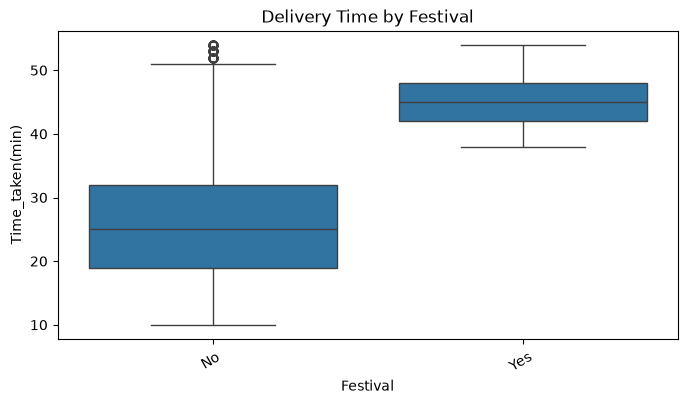

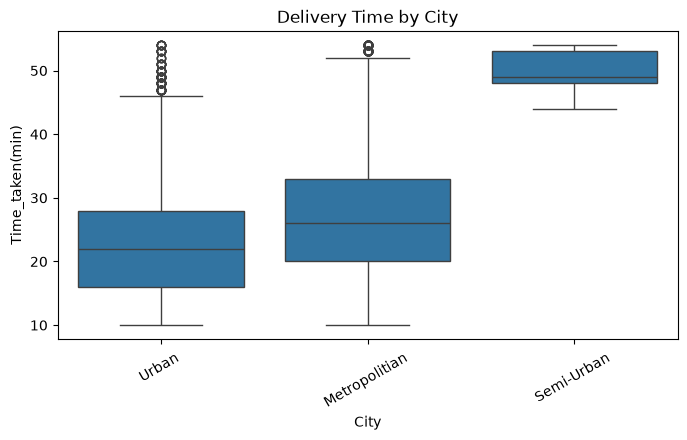

In [20]:
categorical_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_order', 
                     'Type_of_vehicle', 'Festival', 'City']

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col, y='Time_taken(min)')
    plt.title(f'Delivery Time by {col}')
    plt.xticks(rotation=30)
    plt.show()

In [21]:
print(df.groupby('City')['Time_taken(min)'].agg(['mean', 'count']))
print(df.groupby('Festival')['Time_taken(min)'].agg(['mean', 'count']))

                     mean  count
City                            
Metropolitian   27.141597  31279
Semi-Urban      49.680851    141
Urban           23.041196   8933
               mean  count
Festival                  
No        25.931557  39566
Yes       45.471410    787


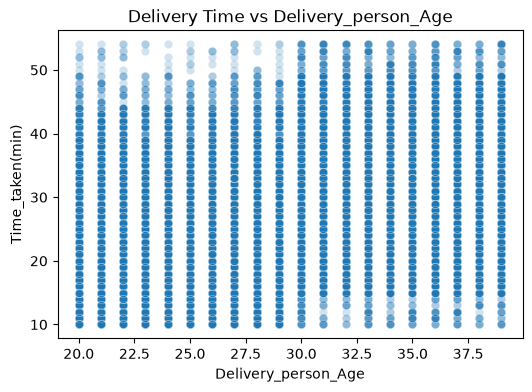

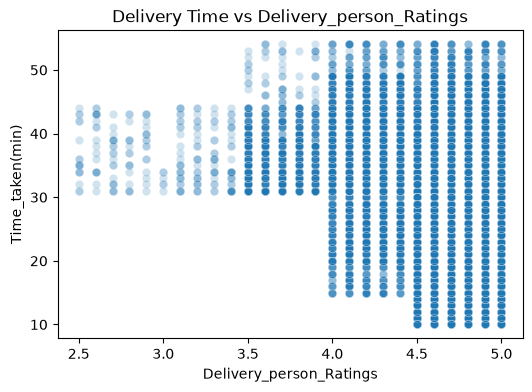

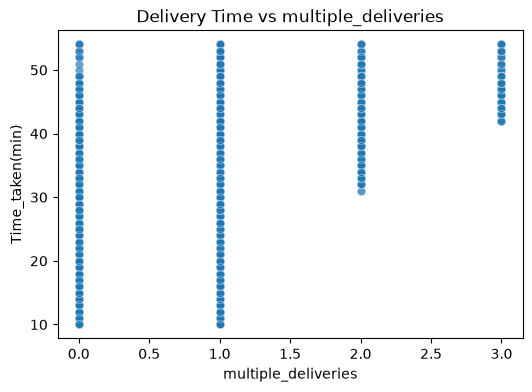

In [23]:
numeric_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y='Time_taken(min)', alpha=0.2)
    plt.title(f'Delivery Time vs {col}')
    plt.show()

In [24]:
print(df.groupby('multiple_deliveries')['Time_taken(min)'].agg(['mean', 'count']))
print(df['Delivery_person_Ratings'].value_counts().sort_index())

                          mean  count
multiple_deliveries                  
0.0                  22.890143  12489
1.0                  26.736187  25772
2.0                  40.425365   1782
3.0                  47.858065    310
Delivery_person_Ratings
2.5      18
2.6      20
2.7      21
2.8      17
2.9      18
3.0       6
3.1      28
3.2      26
3.3      23
3.4      32
3.5     236
3.6     194
3.7     203
3.8     218
3.9     176
4.0     998
4.1    1323
4.2    1331
4.3    1301
4.4    1246
4.5    3067
4.6    6387
4.7    6772
4.8    6558
4.9    6468
5.0    3666
Name: count, dtype: int64
